In [8]:
# %run /Users/tthomas/Desktop/trappist-so2_volcanism/so2_volcanism/atmosphere_model/input_files.py
# %run /Users/tthomas/Desktop/trappist-so2_volcanism/so2_volcanism/atmosphere_model/main.py

Row index: 3
P_surf (bar): 1.00e-02
P_surf (dyn/cm^2): 1.00e+04
Input mixing ratios:
   CO2: 0.181
   H2O: 0.416
   SO2: 0.136
    H2: 0.096
    CO: 0.123
   H2S: 0.005
   CH4: 0.000
    S2: 0.043
Output profile levels: 51
T range (K): 469.94 - 747.01
Returned species: ['1CH2', 'C', 'C2', 'C2H', 'C2H2', 'C2H2OH', 'C2H3', 'C2H3OH', 'C2H4', 'C2H4OH', 'C2H5', 'C2H6', 'C3H4', 'C3H6', 'C4H', 'C4H2', 'C4H3', 'C4H4', 'CH', 'CH2', 'CH2CHO', 'CH2CO', 'CH3', 'CH3CHO', 'CH3CO', 'CH3O', 'CH3O2', 'CH3OH', 'CH4', 'CO', 'CO2', 'CS', 'CS2', 'H', 'H2', 'H2CO', 'H2COH', 'H2O', 'H2O2', 'H2S', 'H2SO4', 'HCCO', 'HCO', 'HCS', 'HO2', 'HS', 'HS4', 'HSO', 'HSO3', 'O', 'O1D', 'O2', 'O3', 'OCS', 'OH', 'S', 'S2', 'S3', 'S4', 'S8', 'SO', 'SO2', 'SO3']
Saved plot to: figures/atm_from_grid_row_3.pdf


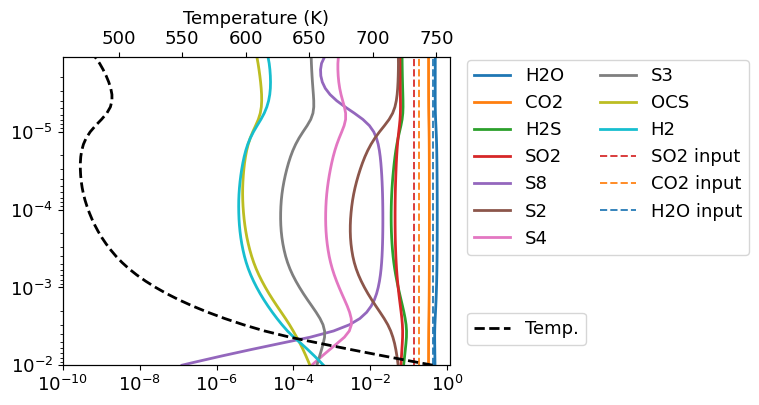

In [7]:
import numpy as np
from atmosphere_model.main import plot, run

grid_path = 'data/grid_1e5samples_MARCH03.npz'
row_index = 3  # change this to sample a different row
plot_filename = f'figures/atm_from_grid_row_{row_index}.pdf'

# Load grid
d = np.load(grid_path, allow_pickle=False)
cols = [str(c) for c in d['columns']]
data = d['data']
idx = {c: i for i, c in enumerate(cols)}

if row_index < 0 or row_index >= data.shape[0]:
    raise IndexError(f'row_index={row_index} is out of bounds for n_rows={data.shape[0]}')

row = data[row_index]

# Surface pressure conversion: bar -> dyn/cm^2
if 'P_tot' not in idx:
    raise KeyError("'P_tot' column not found in grid")
P_tot_bar = float(row[idx['P_tot']])
P_surf = P_tot_bar * 1.0e6

# Map outgassing-grid columns to atmosphere model species names
col_to_species = {
    'x_CO2_atm_input': 'CO2',
    'x_H2O_atm_input': 'H2O',
    'x_SO2_atm_input': 'SO2',
    'x_H2_atm_input': 'H2',
    'x_CO_atm_input': 'CO',
    'x_H2S_atm_input': 'H2S',
    'x_CH4_atm_input': 'CH4',
    'x_S2_atm_input': 'S2',
}

mix = {}
for col, sp in col_to_species.items():
    if col not in idx:
        continue
    val = float(row[idx[col]])
    if np.isfinite(val) and val > 0.0:
        mix[sp] = val

if not mix:
    raise ValueError('No positive finite atmospheric input species were found in this row.')

# Run climate model
P, T, mix_profile = run(P_surf, mix, verbose=False)

print(f'Row index: {row_index}')
print(f'P_surf (bar): {P_tot_bar:.2e}')
print(f'P_surf (dyn/cm^2): {P_surf:.2e}')
print('Input mixing ratios:')
for sp, val in mix.items():
    print(f'  {sp:>4s}: {val:.3f}')

print(f'Output profile levels: {len(P)}')
print(f'T range (K): {np.nanmin(T):.2f} - {np.nanmax(T):.2f}')
print('Returned species:', sorted(mix_profile.keys()))

# Plot and save
plot(P, T, mix_profile, ylim=(P[0] / 1e6, P[-1] / 1e6), filename=plot_filename, input_mix=mix)
print(f'Saved plot to: {plot_filename}')


Matches for P_tot=1e-05 bar and x_SO2_atm_input>0.5: 1452
Using row_index=1104 (match_pick=1)
P_tot=1e-05 bar | x_SO2_atm_input=0.5418
Input species mix:
   CO2: 0.141771
   H2O: 0.042341
   SO2: 0.541753
    H2: 0.023194
    CO: 0.229074
   H2S: 0.000030
   CH4: 0.000000
    S2: 0.021837
Output levels: 51
T range (K): 438.69 - 616.92
Returned species: ['1CH2', 'C', 'C2', 'C2H', 'C2H2', 'C2H2OH', 'C2H3', 'C2H3OH', 'C2H4', 'C2H4OH', 'C2H5', 'C2H6', 'C3H4', 'C3H6', 'C4H', 'C4H2', 'C4H3', 'C4H4', 'CH', 'CH2', 'CH2CHO', 'CH2CO', 'CH3', 'CH3CHO', 'CH3CO', 'CH3O', 'CH3O2', 'CH3OH', 'CH4', 'CO', 'CO2', 'CS', 'CS2', 'H', 'H2', 'H2CO', 'H2COH', 'H2O', 'H2O2', 'H2S', 'H2SO4', 'HCCO', 'HCO', 'HCS', 'HO2', 'HS', 'HS4', 'HSO', 'HSO3', 'O', 'O1D', 'O2', 'O3', 'OCS', 'OH', 'S', 'S2', 'S3', 'S4', 'S8', 'SO', 'SO2', 'SO3']
Saved plot: figures/atm_match_row_1104_P1e-05_xSO2gt0.50.pdf


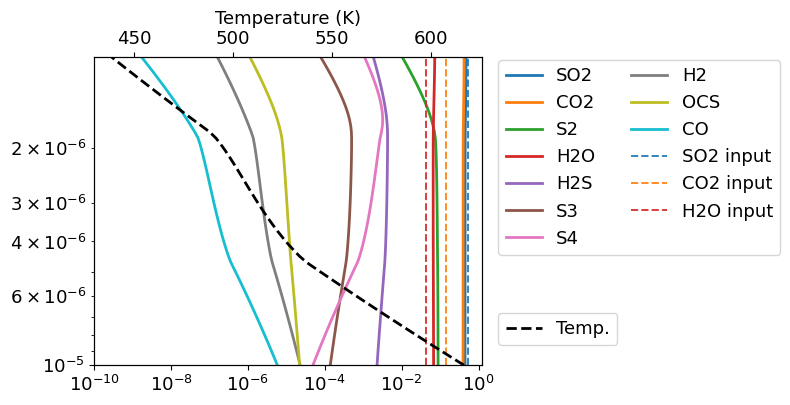

In [4]:
# Filter grid by SO2 and pressure, pick one match, run atmospheric model
import numpy as np
from atmosphere_model.main import plot, run

# Easy-to-change selection parameters
xso2_min = 0.5
pressure_target_bar = 1e-5
pressure_atol_bar = 1e-12   # exact-grid pressures are usually exact; keep small tolerance
match_pick = 1              # 0 = first matching row, 1 = second, etc.

grid_path = 'data/grid_1e5samples_MARCH03.npz'

# Load grid
d = np.load(grid_path, allow_pickle=False)
cols = [str(c) for c in d['columns']]
data = d['data']
idx = {c: i for i, c in enumerate(cols)}

required = ['P_tot', 'x_SO2_atm_input']
missing = [c for c in required if c not in idx]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

p_vals = data[:, idx['P_tot']].astype(float)
so2_vals = data[:, idx['x_SO2_atm_input']].astype(float)

match_mask = (
    np.isfinite(p_vals)
    & np.isfinite(so2_vals)
    & np.isclose(p_vals, pressure_target_bar, rtol=0.0, atol=pressure_atol_bar)
    & (so2_vals > xso2_min)
)
match_indices = np.where(match_mask)[0]

print(f'Matches for P_tot={pressure_target_bar:g} bar and x_SO2_atm_input>{xso2_min}: {len(match_indices)}')
if len(match_indices) == 0:
    raise ValueError('No matching rows found. Try lowering xso2_min or widening pressure_atol_bar.')
if match_pick < 0 or match_pick >= len(match_indices):
    raise IndexError(f'match_pick={match_pick} out of range for {len(match_indices)} matches')

row_index = int(match_indices[match_pick])
row = data[row_index]

# Surface pressure conversion: bar -> dyn/cm^2
P_tot_bar = float(row[idx['P_tot']])
P_surf = P_tot_bar * 1.0e6

# Map outgassing-grid columns to atmosphere model species names
col_to_species = {
    'x_CO2_atm_input': 'CO2',
    'x_H2O_atm_input': 'H2O',
    'x_SO2_atm_input': 'SO2',
    'x_H2_atm_input': 'H2',
    'x_CO_atm_input': 'CO',
    'x_H2S_atm_input': 'H2S',
    'x_CH4_atm_input': 'CH4',
    'x_S2_atm_input': 'S2',
}

mix = {}
for col, sp in col_to_species.items():
    if col not in idx:
        continue
    val = float(row[idx[col]])
    if np.isfinite(val) and val > 0.0:
        mix[sp] = val

if not mix:
    raise ValueError('No positive finite atmospheric input species found in selected row.')

# Run climate model
P, T, mix_profile = run(P_surf, mix, verbose=False)

print(f'Using row_index={row_index} (match_pick={match_pick})')
print(f'P_tot={P_tot_bar:g} bar | x_SO2_atm_input={row[idx["x_SO2_atm_input"]]:.4f}')
print('Input species mix:')
for sp, val in mix.items():
    print(f'  {sp:>4s}: {val:.6f}')

print(f'Output levels: {len(P)}')
print(f'T range (K): {np.nanmin(T):.2f} - {np.nanmax(T):.2f}')
print('Returned species:', sorted(mix_profile.keys()))

# Plot output
plot_filename = f'figures/atm_match_row_{row_index}_P{pressure_target_bar:.0e}_xSO2gt{xso2_min:.2f}.pdf'
plot(P, T, mix_profile, ylim=(P[0]/1e6, P[-1]/1e6), filename=plot_filename, input_mix=mix)
print(f'Saved plot: {plot_filename}')

